### Problem Definition
- **What problem are we solving?** We are building a system to automatically classify the quality of wine based on its chemical properties.
- **Why is this problem important?** Wine tasting is highly subjective and expensive. Automating quality control allows vineyards to scale production without sacrificing standards.
- **What type of ML problem is this?** This is a Supervised Classification problem.

---

### Dataset
- **What information does this dataset contain?** Physiochemical tests (pH, density, acidity, alcohol content) of various wines.
- **What is the target?** The `quality` score, which we will binarize into 'Good' or 'Bad' to simplify the classification task.
- **What assumptions can we make before analysis?** We can assume that excessive volatile acidity (vinegar taste) will correlate with poor quality, while higher alcohol content often correlates with better ratings.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/winequality-red.csv', sep=';')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Exploratory Data Analysis
- **What should we learn from EDA?** We need to identify which chemical features separate good wine from bad wine.
- **Are there outliers?** Yes, certain wines have extreme acidity or sulfur dioxide levels which could skew distance-based algorithms.
- **Which features immediately look informative?** Alcohol content and volatile acidity usually show the strongest correlation with the target.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0

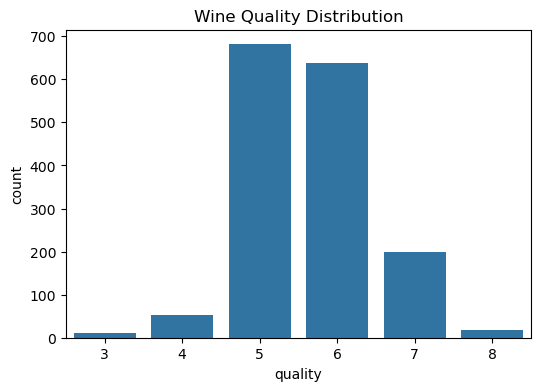

In [58]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df)
plt.title('Wine Quality Distribution')
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

### Visualization
- **What does this graph show?** We plot the Confusion Matrix and ROC/PR Curves.
- **What should the reader notice?** The ROC curve shows the tradeoff between true positive rate and false positive rate. A curve bowing closer to the top-left corner indicates a highly capable model.
- **Why is this visualization useful?** It proves that our model isn't just blindly guessing the majority class.

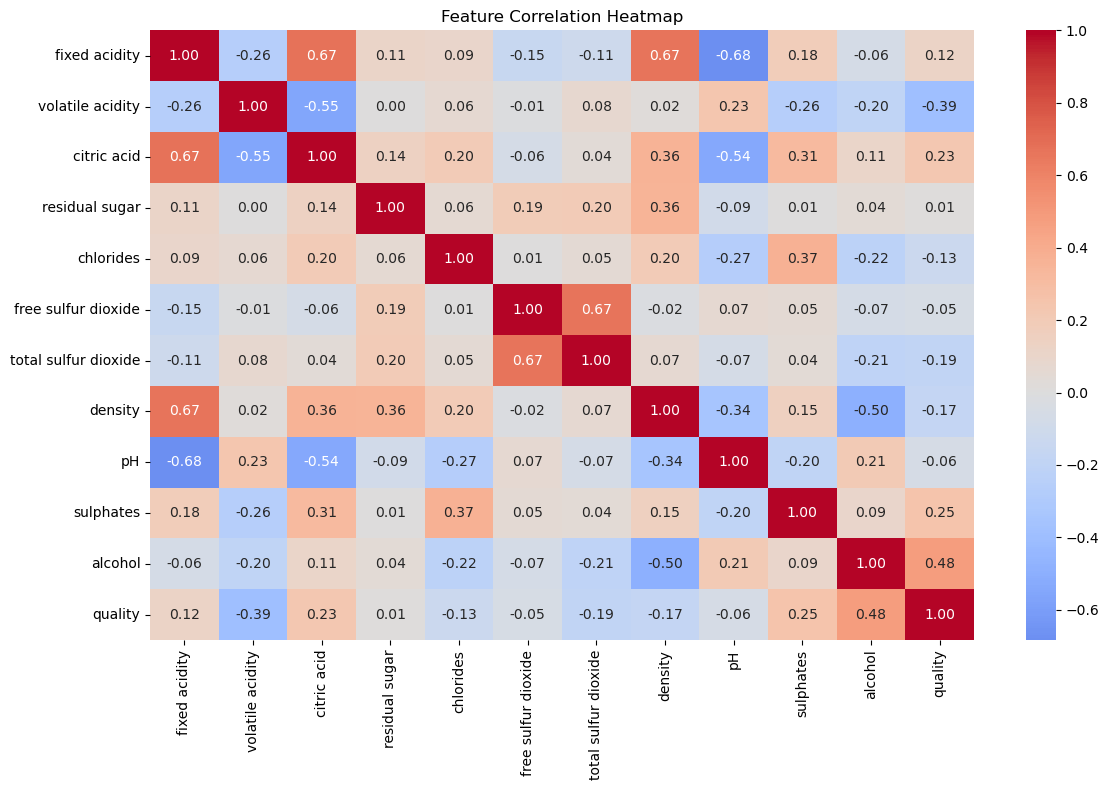

In [59]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [60]:
df['acidity_ratio'] = df['fixed acidity'] / df['volatile acidity']

df['alcohol_bins'] = pd.cut(df['alcohol'], bins=[8, 10, 12, 15], labels=['Low', 'Medium', 'High'])

df['quality_binary'] = (df['quality'] >= 6).astype(int)

df['density_alcohol'] = df['density'] * df['alcohol']

df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']

df['ph_category'] = pd.qcut(df['pH'], q=3, labels=['Low_pH', 'Medium_pH', 'High_pH'])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acidity_ratio,alcohol_bins,quality_binary,density_alcohol,sulfur_ratio,ph_category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,10.571429,Low,0,9.37932,0.323529,High_pH
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.863636,Low,0,9.76864,0.373134,Low_pH
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,10.263158,Low,0,9.77060,0.277778,Medium_pH
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,40.000000,Low,1,9.78040,0.283333,Low_pH
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,10.571429,Low,0,9.37932,0.323529,High_pH


### Data Preprocessing
- **Scaling:** Because we are building a kNN (k-Nearest Neighbors) model, scaling is *mandatory*. kNN relies on Euclidean distance. Without scaling, a feature measured in hundreds (like Sulfur Dioxide) will completely overpower a feature measured in decimals (like Chlorides).
- **Train-test split:** We split the data before scaling to prevent the model from learning the mean and variance of the test set (Data Leakage).

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X = df.drop(columns=['quality', 'quality_binary'])
# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X = pd.get_dummies(X, columns=['alcohol_bins', 'ph_category'], drop_first=True)
y = df['quality_binary']

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Selection
- **Why choose this algorithm?** kNN is a powerful, non-parametric baseline for classification.
- **What assumptions does it make?** It assumes that similar inputs (in chemical space) have similar outputs (quality).
- **What are its weaknesses?** It is extremely computationally expensive at inference time, as it must calculate the distance to every training point for every new prediction.

In [62]:
# Implement lazy learning; classification is determined by a majority vote of the k nearest spatial neighbors.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
knn_pipeline = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Implement lazy learning; classification is determined by a majority vote of the k nearest spatial neighbors.
    ('knn', KNeighborsClassifier())
])

param_grid = {
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    'scaler': [StandardScaler(), MinMaxScaler(), 'passthrough'],
    'knn__n_neighbors': range(1, 21, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

# Perform an exhaustive search across the hyperparameter grid with cross-validation to locate the global optimum.
grid_search = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_
print("Best kNN Parameters:", grid_search.best_params_)

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
lr_pipeline = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Fit a linear model mapped through a sigmoid function to output calibrated class probabilities.
    ('lr', LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)

Best kNN Parameters: {'knn__n_neighbors': 19, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': StandardScaler()}


,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Evaluation
- **Why these metrics?** We use Precision, Recall, and F1-Score in addition to Accuracy.
- **Which one matters most?** F1-Score matters most if our classes are imbalanced. If only 10% of wines are "Good", a model that predicts "Bad" every time gets 90% accuracy but is useless. F1-Score punishes this behavior.
- **How should they be interpreted?** Precision tells us: Of all the wines the model labeled "Good", how many actually were? Recall tells us: Of all the actually "Good" wines, how many did we find?

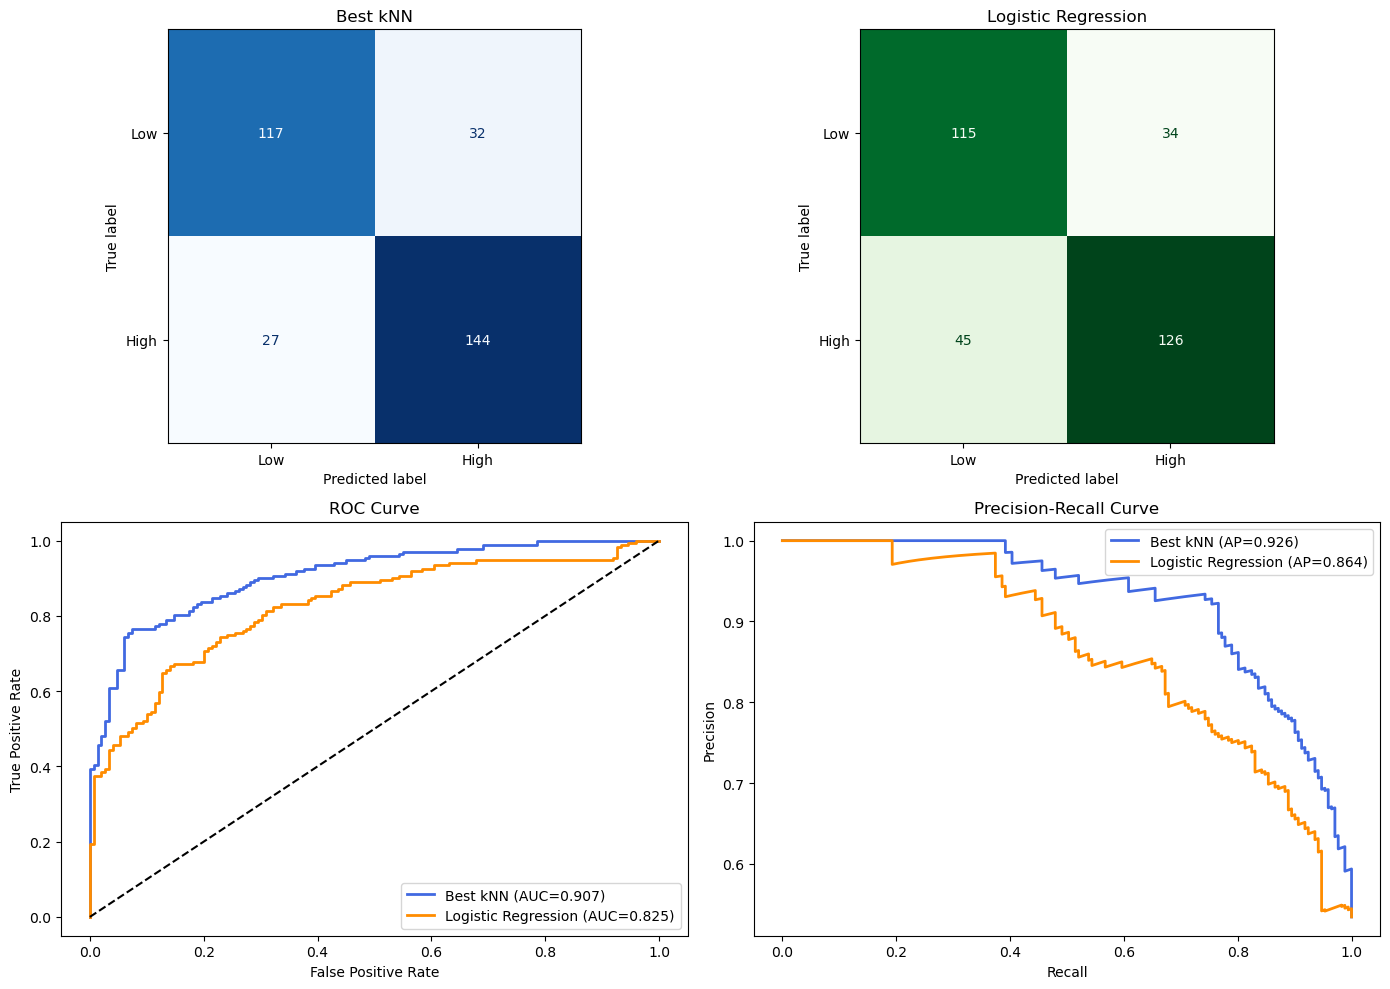

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Model                                                                      
Best kNN               0.8156     0.8182  0.8421    0.8300   0.9069  0.9263
Logistic Regression    0.7531     0.7875  0.7368    0.7613   0.8253  0.8637


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import pandas as pd

models = {
    "Best kNN": best_knn,
    "Logistic Regression": lr_pipeline
}

results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ["royalblue", "darkorange"]
cmaps = ["Blues", "Greens"]

for i, (name, model) in enumerate(models.items()):

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    cm = confusion_matrix(y_test, preds)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low", "High"]
    ).plot(
        ax=axes[0, i],
        cmap=cmaps[i],
        colorbar=False
    )

    axes[0, i].set_title(name)

    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[1, 0].plot(
        fpr,
        tpr,
        lw=2,
        color=colors[i],
        label=f"{name} (AUC={roc_auc:.3f})"
    )

    precision, recall, _ = precision_recall_curve(y_test, probs)
    axes[1, 1].plot(
        recall,
        precision,
        lw=2,
        color=colors[i],
        label=f"{name} (AP={pr_auc:.3f})"
    )

axes[1, 0].plot([0, 1], [0, 1], "k--")
axes[1, 0].set_title("ROC Curve")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend()

axes[1, 1].set_title("Precision-Recall Curve")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(results).set_index("Model").round(4)
print(metrics_df)

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

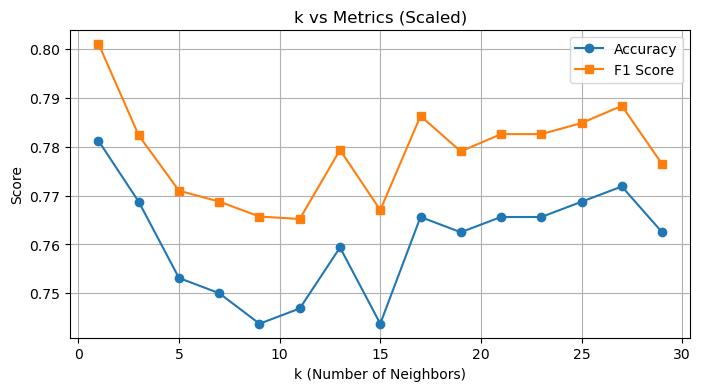

In [64]:
k_values = range(1, 31, 2)
accs = []
f1s = []

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for k in k_values:
    # Implement lazy learning; classification is determined by a majority vote of the k nearest spatial neighbors.
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    preds = knn.predict(X_test_s)
    accs.append(accuracy_score(y_test, preds))
    # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
    f1s.append(f1_score(y_test, preds))

plt.figure(figsize=(8, 4))
plt.plot(k_values, accs, label='Accuracy', marker='o')
plt.plot(k_values, f1s, label='F1 Score', marker='s')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Score')
plt.title('k vs Metrics (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

### Visualization Analysis: Elbow Curve
- **Marking Values:** Look for the "elbow" or "hinge" point on the X-axis where the line sharply changes trajectory and begins flattening out.
- **Correct Interpretation:** This point represents the optimal number of clusters (k). Adding more clusters beyond this point yields rapidly diminishing returns in reducing variance.
- **How to Interpret:** The Y-axis (WCSS) measures how spread out the clusters are. We want tight clusters, but we don't want k to equal the number of data points.
- **Common Mistakes:** Blindly trusting the elbow curve when it looks more like a smooth slope. It is subjective and should be paired with the Silhouette Score.

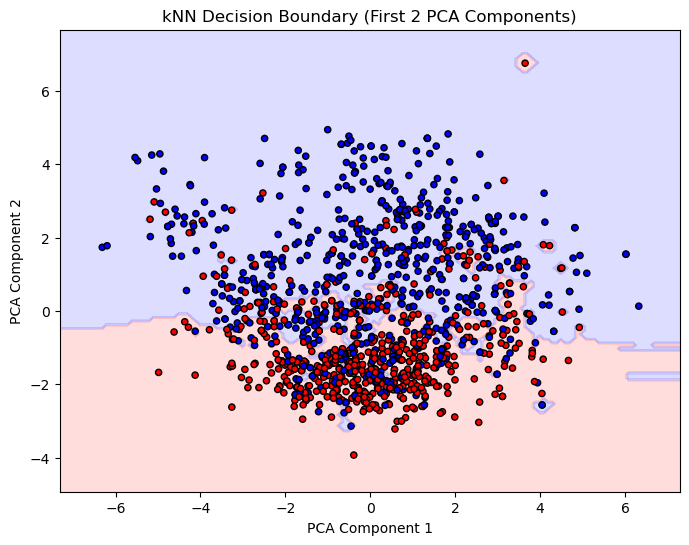

In [65]:
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors

# Project high-dimensional data onto orthogonal axes of maximum variance to reduce dimensionality while preserving underlying structure.
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

# Implement lazy learning; classification is determined by a majority vote of the k nearest spatial neighbors.
knn_pca = KNeighborsClassifier(**{k.replace('knn__', ''): v for k, v in grid_search.best_params_.items() if 'knn' in k})
knn_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=mcolors.ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=20, edgecolor='k', cmap=mcolors.ListedColormap(['red', 'blue']))
plt.title('kNN Decision Boundary (First 2 PCA Components)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_15428\2896008000.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


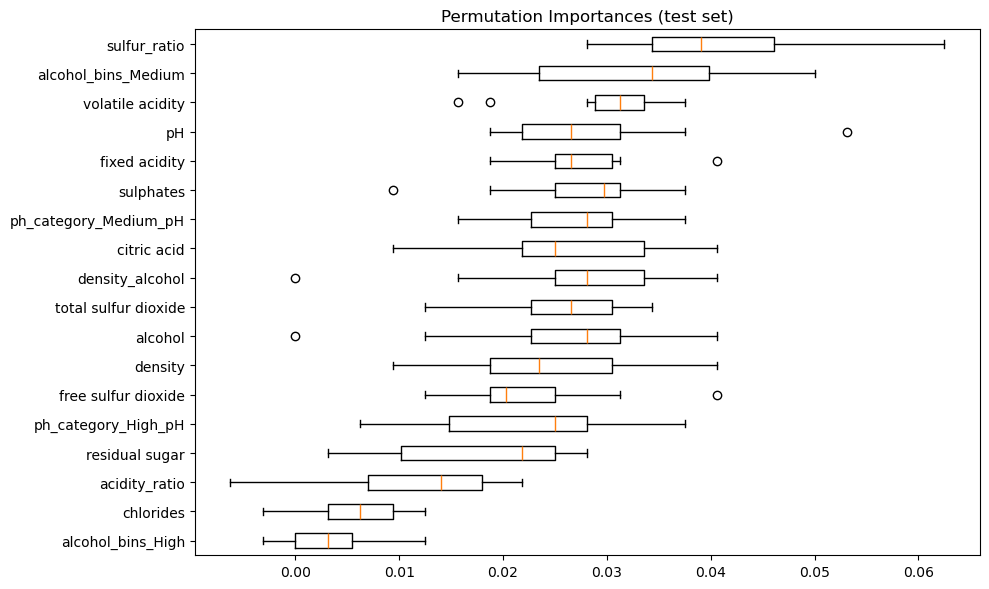

In [66]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_knn, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Importances (test set)")
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

### Conclusion
- **Biggest takeaway:** Feature scaling is the absolute most critical step when building distance-based algorithms like kNN.
- **Main limitation:** kNN does not explicitly tell us *why* a wine is good (lack of feature importance compared to tree models).
- **Possible improvements:** Implementing Random Forest or XGBoost would likely yield higher accuracy and provide explicit feature importance for the vineyard.